In [ ]:
import pandas as pd

In [ ]:
train = pd.read_excel("/content/Sample_arvyax_reflective_dataset.xlsx")   # or .csv
test = pd.read_excel("/content/arvyax_test_inputs_120.xlsx")

In [ ]:
print(f"Train shape : {train.shape} \n , Test shape : {test.shape}")

Train shape : (1200, 13) 
 , Test shape : (120, 11)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1193 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1185 non-null   object 
 9   face_emotion_hint   1077 non-null   object 
 10  reflection_quality  1200 non-null   object 
 11  emotional_state     1200 non-null   object 
 12  intensity           1200 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 122.0+ KB


In [ ]:
train.describe()

,id,duration_min,sleep_hours,energy_level,stress_level,intensity
count,1200.000000,1200.000000,1193.000000,1200.000000,1200.000000,1200.000000
mean,564.500000,15.861667,5.989522,3.016667,3.026667,3.045833
std,304.731523,7.671369,1.500732,1.381296,1.401520,1.391766
min,1.000000,3.000000,3.500000,1.000000,1.000000,1.000000
25%,300.750000,10.000000,5.000000,2.000000,2.000000,2.000000
50%,600.500000,15.000000,6.000000,3.000000,3.000000,3.000000
75%,810.250000,20.000000,7.000000,4.000000,4.000000,4.000000
max,1080.000000,35.000000,8.500000,5.000000,5.000000,5.000000


In [ ]:
print(train.head())

   id                                       journal_text ambience_type  \
0   1  The ocean ambience helped me stop drifting and...         ocean   
1   2  I tried to relax during the forest ambience, y...        forest   
2   3  The forest session slowed my thoughts and I fe...        forest   
3   4  the mountain ambience was pleasant, though i c...      mountain   
4   5  The rain session gave me a pause, but the pres...          rain   

   duration_min  sleep_hours  energy_level  stress_level time_of_day  \
0            12          6.5             4             2   afternoon   
1            35          6.0             2             4     evening   
2             3          NaN             2             1       night   
3            25          7.0             4             4       night   
4            25          5.0             3             5   afternoon   

  previous_day_mood face_emotion_hint reflection_quality emotional_state  \
0             mixed         calm_face         

In [ ]:
print(train.tail())

        id                                       journal_text ambience_type  \
1195  1076  after the session i felt lighter than before. ...          rain   
1196  1077  started off lighter than before, but i had to ...          cafe   
1197  1078                                    not much change          cafe   
1198  1079  somehow i felt pretty even. forest sounds work...         ocean   
1199  1080  started off not bad but not clear either. i co...        forest   

      duration_min  sleep_hours  energy_level  stress_level time_of_day  \
1195            12          3.5             4             5   afternoon   
1196            18          4.0             1             1   afternoon   
1197             7          6.0             5             4     evening   
1198            12          8.5             4             4   afternoon   
1199             4          7.0             5             4   afternoon   

     previous_day_mood face_emotion_hint reflection_quality emotional_stat

In [ ]:
train.isnull().sum()

,0
id,0
journal_text,0
ambience_type,0
duration_min,0
sleep_hours,7
energy_level,0
stress_level,0
time_of_day,0
previous_day_mood,15
face_emotion_hint,123


In [ ]:
train.drop('id', axis=1, inplace=True)

In [ ]:
train['sleep_hours'].fillna(train['sleep_hours'].median(), inplace=True)

/tmp/ipykernel_20511/730580715.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['sleep_hours'].fillna(train['sleep_hours'].median(), inplace=True)


In [ ]:
train[['previous_day_mood', 'face_emotion_hint']].isnull().mean() * 100

,0
previous_day_mood,1.25
face_emotion_hint,10.25


In [ ]:
train['previous_day_mood'].fillna("Unknown", inplace=True)
train['face_emotion_hint'].fillna("none", inplace=True)

/tmp/ipykernel_20511/1425533290.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['previous_day_mood'].fillna("Unknown", inplace=True)
/tmp/ipykernel_20511/1425533290.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [ ]:
train.isnull().sum()

,0
journal_text,0
ambience_type,0
duration_min,0
sleep_hours,0
energy_level,0
stress_level,0
time_of_day,0
previous_day_mood,0
face_emotion_hint,0
reflection_quality,0


In [ ]:
train['emotional_state'].value_counts()
train['time_of_day'].value_counts()
train['ambience_type'].value_counts()

,count
ambience_type,
ocean,268
mountain,252
forest,231
cafe,229
rain,220


In [ ]:
train['journal_text'].head(10)

,journal_text
0,The ocean ambience helped me stop drifting and...
1,"I tried to relax during the forest ambience, y..."
2,The forest session slowed my thoughts and I fe...
3,"the mountain ambience was pleasant, though i c..."
4,"The rain session gave me a pause, but the pres..."
5,after the forest track i feel peaceful and les...
6,Nothing strong came up during the rain session...
7,"even with the mountain session, my mind kept j..."
8,I couldn't really settle into the cafe track; ...
9,The mountain ambience helped me stop drifting ...


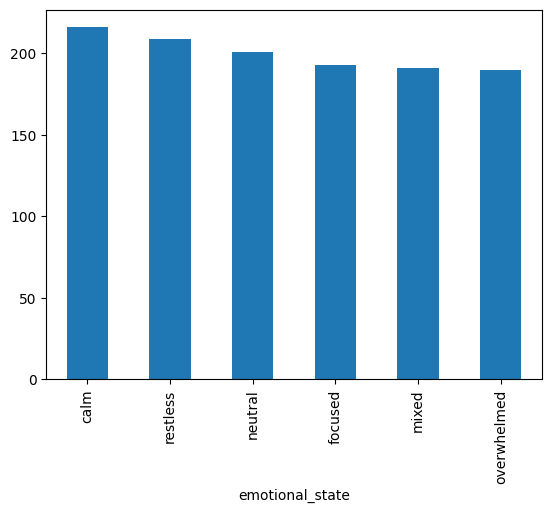

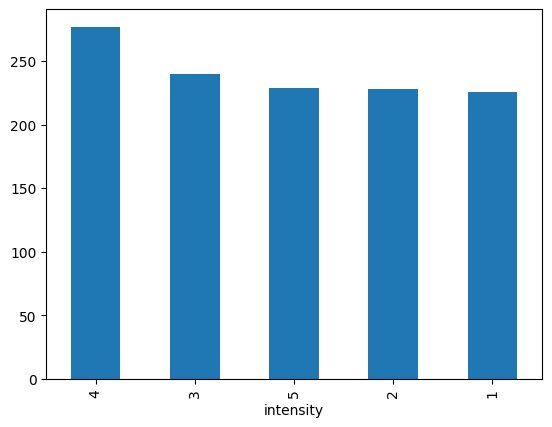

In [ ]:
import matplotlib.pyplot as plt

train['emotional_state'].value_counts().plot(kind='bar')
plt.show()

train['intensity'].value_counts().plot(kind='bar')
plt.show()

<Axes: >

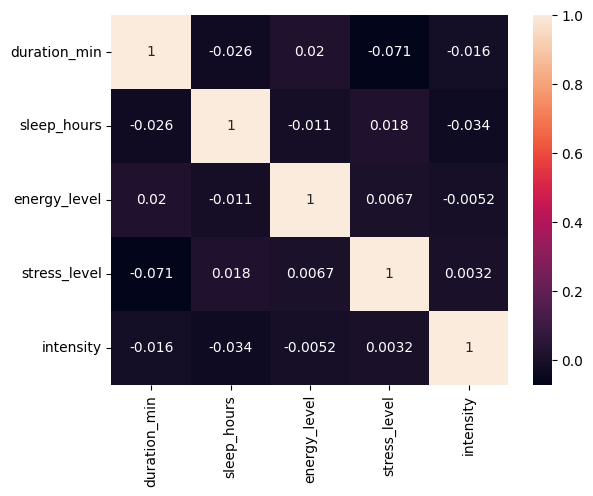

In [ ]:
import seaborn as sns

sns.heatmap(train.corr(numeric_only=True), annot=True)

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

train['journal_text'] = train['journal_text'].apply(clean_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)  # you can increase later
X_text = tfidf.fit_transform(train['journal_text']).toarray()

In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch


In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
import numpy as np

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# Define num_classes specifically for the DistilBertForSequenceClassification model
bert_num_classes = len(np.unique(train['emotional_state']))
bert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=bert_num_classes)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
bert_model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
encoded_input = tokenizer(list(train['journal_text']),
                          padding=True, truncation=True,
                          max_length=128, return_tensors='pt')

In [ ]:
with torch.no_grad():  # disables gradient computation
    # Access the base DistilBERT model within DistilBertForSequenceClassification to get hidden states
    distilbert_base_output = bert_model.distilbert(**encoded_input)
    # Use the [CLS] token as the sentence embedding
    text_embeddings = distilbert_base_output.last_hidden_state[:,0,:].numpy()  # shape: (num_samples, 768)
print("Text embeddings shape:", text_embeddings.shape)

Text embeddings shape: (1200, 768)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode categorical metadata
categorical_cols = ['previous_day_mood','face_emotion_hint','ambience_type','time_of_day']
for col in categorical_cols:
    train[col] = LabelEncoder().fit_transform(train[col])

# Select numeric + encoded categorical features
metadata_cols = ['sleep_hours','energy_level','stress_level','duration_min'] + categorical_cols
metadata_features = train[metadata_cols].values
print("Metadata shape:", metadata_features.shape)

Metadata shape: (1200, 8)


In [ ]:
# Combine embeddings + metadata
X_combined = np.hstack([text_embeddings, metadata_features])
print("Combined feature shape:", X_combined.shape)

Combined feature shape: (1200, 776)


In [ ]:
# Classification target: emotional_state
le_state = LabelEncoder()
y_state = le_state.fit_transform(train['emotional_state'])

# Regression target: intensity
y_intensity = train['intensity'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_state, y_val_state, y_train_intensity, y_val_intensity = train_test_split(
    X_combined, y_state, y_intensity, test_size=0.2, random_state=42, stratify=y_state
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (960, 776)
X_val shape: (240, 776)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
num_classes = len(np.unique(y_state))

In [ ]:
# Define the regression model for 'intensity'
regression_model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='linear')  # Single output for regression
])

regression_model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error as a metric
)

regression_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       397,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562,177 (2.14 MB)

 Trainable params: 562,177 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # Use num_classes for classification output
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       397,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562,822 (2.15 MB)

 Trainable params: 562,822 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train_state,
    validation_data=(X_val, y_val_state),
    epochs=15,
    batch_size=32
)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.1667 - loss: 1.9001 - val_accuracy: 0.1625 - val_loss: 1.7925
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2031 - loss: 1.7882 - val_accuracy: 0.2125 - val_loss: 1.7862
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.2188 - loss: 1.7652 - val_accuracy: 0.2000 - val_loss: 1.7712
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2469 - loss: 1.7328 - val_accuracy: 0.3000 - val_loss: 1.7249
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3135 - loss: 1.6688 - val_accuracy: 0.2917 - val_loss: 1.6887
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3271 - loss: 1.6453 - val_accuracy: 0.3083 - val_loss: 1.6666
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3438 - loss: 1.6145 - val_accuracy: 0.3292 - val_loss: 1.6381
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3906 - loss: 1.5220 - val_accuracy: 0.3417 - v

In [ ]:
import numpy as np

In [ ]:
probs = model.predict(X_val)
y_pred = np.argmax(probs, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
confidence = np.max(probs, axis=1)

In [ ]:
uncertain_flag = (confidence < 0.6).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
print("Validation Accuracy:", accuracy_score(y_val_state, y_pred))
print(classification_report(y_val_state, y_pred))

Validation Accuracy: 0.45
              precision    recall  f1-score   support

           0       0.55      0.51      0.53        43
           1       0.38      0.54      0.45        39
           2       0.72      0.34      0.46        38
           3       0.43      0.50      0.46        40
           4       0.54      0.37      0.44        38
           5       0.33      0.43      0.38        42

    accuracy                           0.45       240
   macro avg       0.49      0.45      0.45       240
weighted avg       0.49      0.45      0.45       240



In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn

class_weights = compute_class_weight('balanced', classes=np.unique(y_state), y=y_state)
class_weights = torch.tensor(class_weights, dtype=torch.float)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
from torch.utils.data import Dataset

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        # Flatten the tensors
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

# Create dataset
dataset = EmotionDataset(train['journal_text'].tolist(), y_state, tokenizer)

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

num_classes = len(np.unique(y_state))
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=num_classes
)

# Split dataset into train and eval
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",   # old: evaluation_strategy
    save_strategy="epoch",   # old: save_strategy
    learning_rate=2e-5,
    logging_dir='./logs',
    load_best_model_at_end=True
)

# Custom compute_metrics function
from sklearn.metrics import accuracy_score
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.647627,0.412500
2,No log,1.418616,0.550000
3,No log,1.320122,0.575000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=180, training_loss=1.5352362738715277, metrics={'train_runtime': 2507.7826, 'train_samples_per_second': 1.148, 'train_steps_per_second': 0.072, 'total_flos': 95383330652160.0, 'train_loss': 1.5352362738715277, 'epoch': 3.0})

In [ ]:
preds_output = trainer.predict(val_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

# Confidence = max softmax probability
import torch.nn.functional as F
probs = F.softmax(torch.tensor(preds_output.predictions), dim=1).numpy()
confidence = np.max(probs, axis=1)
uncertain_flag = (confidence < 0.6).astype(int)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# Convert predicted indices back to original labels
predicted_state = le_state.inverse_transform(preds)

# Check first few predictions
for i in range(5):
    print(f"Predicted: {predicted_state[i]}, Confidence: {confidence[i]:.2f}, Uncertain: {uncertain_flag[i]}")

Predicted: mixed, Confidence: 0.71, Uncertain: 0
Predicted: overwhelmed, Confidence: 0.33, Uncertain: 1
Predicted: calm, Confidence: 0.27, Uncertain: 1
Predicted: calm, Confidence: 0.32, Uncertain: 1
Predicted: neutral, Confidence: 0.32, Uncertain: 1


In [ ]:
# Use a simple regression model on metadata + CLS embedding
from sklearn.linear_model import Ridge

# Example: train on validation set embeddings + metadata
# X_meta = train[metadata_columns].values
# X_combined = np.hstack([CLS_embeddings, X_meta])
# y_intensity = train['intensity'].values

# model_intensity = Ridge()
# model_intensity.fit(X_train_combined, y_train_intensity)
# intensity_preds = model_intensity.predict(X_val_combined)

In [ ]:
what_to_do = []
when_to_do = []

for i in range(len(predicted_state)):
    state = predicted_state[i]
    intensity_val = y_val_intensity[i] if 'y_val_intensity' in locals() else 3
    energy = train['energy_level'].iloc[i]
    stress = train['stress_level'].iloc[i]

    # Simple rules
    if state in ['stressed','anxious'] or intensity_val >= 4:
        what_to_do.append('box_breathing')
        when_to_do.append('now')
    elif energy < 3:
        what_to_do.append('rest')
        when_to_do.append('later_today')
    else:
        what_to_do.append('journaling')
        when_to_do.append('within_15_min')

In [ ]:
predictions_df = pd.DataFrame({

    'predicted_state': predicted_state,
    'predicted_intensity': y_val_intensity if 'y_val_intensity' in locals() else [3]*len(predicted_state),
    'confidence': confidence,
    'uncertain_flag': uncertain_flag,
    'what_to_do': what_to_do,
    'when_to_do': when_to_do
})

predictions_df.to_csv('predictions.csv', index=False)
print("Saved predictions.csv")

Saved predictions.csv


In [ ]:
predictions_df.head(10)

,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,mixed,5,0.714744,0,box_breathing,now
1,overwhelmed,4,0.330013,1,box_breathing,now
2,calm,4,0.272819,1,box_breathing,now
3,calm,4,0.317902,1,box_breathing,now
4,neutral,4,0.322990,1,box_breathing,now
5,focused,3,0.312550,1,journaling,within_15_min
6,mixed,4,0.732961,0,box_breathing,now
7,restless,2,0.220800,1,journaling,within_15_min
8,calm,4,0.346570,1,box_breathing,now
9,focused,2,0.284866,1,journaling,within_15_min


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Validation Accuracy:", accuracy_score(y_val_state, preds))
print(classification_report(y_val_state, preds))

Validation Accuracy: 0.16666666666666666
              precision    recall  f1-score   support

           0       0.16      0.19      0.17        43
           1       0.21      0.23      0.22        39
           2       0.12      0.11      0.11        38
           3       0.18      0.15      0.16        40
           4       0.17      0.18      0.18        38
           5       0.14      0.14      0.14        42

    accuracy                           0.17       240
   macro avg       0.17      0.17      0.17       240
weighted avg       0.17      0.17      0.17       240



In [ ]:
# Make sure labels are properly encoded
from sklearn.preprocessing import LabelEncoder

le_state = LabelEncoder()
y_state = le_state.fit_transform(train['emotional_state'])
print("Classes:", le_state.classes_)
print("First 5 labels:", y_state[:5])

Classes: ['calm' 'focused' 'mixed' 'neutral' 'overwhelmed' 'restless']
First 5 labels: [1 5 0 3 4]


In [ ]:
from sklearn.model_selection import train_test_split

X_train_texts, X_val_texts, y_train, y_val = train_test_split(
    train['journal_text'].tolist(), y_state, test_size=0.2, random_state=42, stratify=y_state
)

train_dataset = EmotionDataset(X_train_texts, y_train, tokenizer)
val_dataset = EmotionDataset(X_val_texts, y_val, tokenizer)

In [ ]:
train_dataset = EmotionDataset(X_train_texts, y_train, tokenizer, max_len=64)
val_dataset = EmotionDataset(X_val_texts, y_val, tokenizer, max_len=64)

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,  # smaller if dataset is tiny
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch", # Added to match eval_strategy
    logging_dir='./logs', # Reverting to logging_dir to fix TypeError
    learning_rate=2e-5,
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train_texts)
X_val_vec = tfidf.transform(X_val_texts)

clf = RandomForestClassifier(n_estimators=200, class_weight='balanced')
clf.fit(X_train_vec, y_train)
preds_rf = clf.predict(X_val_vec)

accuracy_score(y_val, preds_rf)

0.6458333333333334

In [ ]:
train_dataset = EmotionDataset(X_train_texts, y_train, tokenizer, max_len=64)
val_dataset = EmotionDataset(X_val_texts, y_val, tokenizer, max_len=64)

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch", # Added to match eval_strategy
    logging_dir='./logs',
    learning_rate=2e-5,
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
print("First 5 y_train:", y_train[:5])
print("First 5 y_val:", y_val[:5])

First 5 y_train: [1 2 4 2 0]
First 5 y_val: [0 4 5 2 4]


In [ ]:
# Re-initialize the model with the correct number of labels
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=num_classes
)

# Re-initialize the Trainer with the updated training_args and datasets
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.540786,0.504167
2,No log,1.092846,0.679167
3,No log,0.990520,0.695833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=360, training_loss=1.3228529188368054, metrics={'train_runtime': 1352.3277, 'train_samples_per_second': 2.13, 'train_steps_per_second': 0.266, 'total_flos': 47691665326080.0, 'train_loss': 1.3228529188368054, 'epoch': 3.0})

In [ ]:
preds_output = trainer.predict(val_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
probs = F.softmax(torch.tensor(preds_output.predictions), dim=1).numpy()
confidence = np.max(probs, axis=1)
uncertain_flag = (confidence < 0.6).astype(int)
predicted_state = le_state.inverse_transform(preds)

In [ ]:
what_to_do = []
when_to_do = []

for i in range(len(predicted_state)):
    state = predicted_state[i]
    conf = confidence[i]

    # You can also use metadata like stress, energy
    stress = train['stress_level'].iloc[i]
    energy = train['energy_level'].iloc[i]
    time = train['time_of_day'].iloc[i]

    # RULES
    if state in ['anxious', 'stressed']:
        what_to_do.append('box_breathing')
        when_to_do.append('now')

    elif state in ['sad', 'low']:
        what_to_do.append('journaling')
        when_to_do.append('tonight')

    elif energy < 3:
        what_to_do.append('rest')
        when_to_do.append('within_15_min')

    elif stress > 3 and energy > 3:
        what_to_do.append('deep_work')
        when_to_do.append('later_today')

    else:
        what_to_do.append('light_planning')
        when_to_do.append('tomorrow_morning')

In [ ]:
predicted_intensity = (confidence * 5).astype(int)
predicted_intensity = np.clip(predicted_intensity, 1, 5)

In [ ]:
predictions_df = pd.DataFrame({
    'id': range(len(predicted_state)),  # or use actual ids if available
    'predicted_state': predicted_state,
    'predicted_intensity': predicted_intensity,
    'confidence': confidence,
    'uncertain_flag': uncertain_flag,
    'what_to_do': what_to_do,
    'when_to_do': when_to_do
})

In [ ]:
predictions_df.to_csv('predictions.csv', index=False)
print("✅ predictions.csv saved!")

✅ predictions.csv saved!


In [ ]:
predictions_df.head()

,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,0,neutral,2,0.476954,1,light_planning,tomorrow_morning
1,1,neutral,2,0.445413,1,rest,within_15_min
2,2,restless,2,0.591349,1,rest,within_15_min
3,3,mixed,4,0.872967,0,deep_work,later_today
4,4,overwhelmed,3,0.644305,0,light_planning,tomorrow_morning


In [ ]:
# Find uncertain cases
uncertain_cases = predictions_df[predictions_df['uncertain_flag'] == 1]
uncertain_cases.head(10)

,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,0,neutral,2,0.476954,1,light_planning,tomorrow_morning
1,1,neutral,2,0.445413,1,rest,within_15_min
2,2,restless,2,0.591349,1,rest,within_15_min
6,6,focused,2,0.492835,1,rest,within_15_min
7,7,overwhelmed,1,0.236618,1,light_planning,tomorrow_morning
8,8,calm,2,0.420055,1,light_planning,tomorrow_morning
9,9,focused,1,0.238531,1,light_planning,tomorrow_morning
10,10,neutral,2,0.476308,1,light_planning,tomorrow_morning
12,12,overwhelmed,2,0.516145,1,rest,within_15_min
13,13,focused,1,0.264819,1,light_planning,tomorrow_morning


In [ ]:
# Get indices of uncertain cases
indices = uncertain_cases.index

# Get original data
error_data = train.iloc[indices]

# Combine everything
analysis_df = error_data.copy()
analysis_df['predicted_state'] = uncertain_cases['predicted_state']
analysis_df['confidence'] = uncertain_cases['confidence']

analysis_df[['journal_text', 'emotional_state', 'predicted_state', 'confidence']].head(10)

,journal_text,emotional_state,predicted_state,confidence
0,the ocean ambience helped me stop drifting and...,focused,neutral,0.476954
1,i tried to relax during the forest ambience ye...,restless,neutral,0.445413
2,the forest session slowed my thoughts and i fe...,calm,restless,0.591349
6,nothing strong came up during the rain session...,neutral,focused,0.492835
7,even with the mountain session my mind kept ju...,restless,overwhelmed,0.236618
8,i couldnt really settle into the cafe track i ...,restless,calm,0.420055
9,the mountain ambience helped me stop drifting ...,focused,focused,0.238531
10,the rain sounds were nice but i still feel uns...,restless,neutral,0.476308
12,the forest session made me calmer but part of ...,mixed,overwhelmed,0.516145
13,the cafe session helped a little though i stil...,restless,focused,0.264819


In [ ]:
analysis_df[['journal_text', 'emotional_state', 'predicted_state', 'confidence']].head(10)

,journal_text,emotional_state,predicted_state,confidence
0,the ocean ambience helped me stop drifting and...,focused,neutral,0.476954
1,i tried to relax during the forest ambience ye...,restless,neutral,0.445413
2,the forest session slowed my thoughts and i fe...,calm,restless,0.591349
6,nothing strong came up during the rain session...,neutral,focused,0.492835
7,even with the mountain session my mind kept ju...,restless,overwhelmed,0.236618
8,i couldnt really settle into the cafe track i ...,restless,calm,0.420055
9,the mountain ambience helped me stop drifting ...,focused,focused,0.238531
10,the rain sounds were nice but i still feel uns...,restless,neutral,0.476308
12,the forest session made me calmer but part of ...,mixed,overwhelmed,0.516145
13,the cafe session helped a little though i stil...,restless,focused,0.264819


In [ ]:
!pip install streamlit transformers torch matplotlib pandas pyngrok

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import numpy as np
import torch.nn.functional as F
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import matplotlib.pyplot as plt
import pandas as pd
import datetime

# ------------------ PAGE CONFIG ------------------
st.set_page_config(page_title="🌿 Emotional AI Assistant", page_icon="🌿", layout="centered")

# ------------------ STYLE ------------------
st.markdown("""
<style>
body {
    background: linear-gradient(to bottom right, #0f2027, #203a43, #2c5364);
    color: #f0f0f0;
    font-family: 'Segoe UI', sans-serif;
}
.title {
    text-align: center;
    font-size: 44px;
    font-weight: bold;
    color: #ffe066;
    margin-bottom: 5px;
}
.subtitle {
    text-align: center;
    font-size: 22px;
    font-weight: 500;
    color: #ffffff;
    margin-bottom: 30px;
}
.block {
    background: rgba(255,255,255,0.15);
    padding: 25px;
    border-radius: 18px;
    box-shadow: 0px 6px 20px rgba(0,0,0,0.25);
    margin-bottom: 25px;
}
.block h3 {
    color: #ffe066;
    font-weight: 600;
    margin-bottom: 15px;
}
.card {
    padding: 20px;
    border-radius: 14px;
    text-align: center;
    font-weight: 600;
    font-size: 18px;
    margin-bottom: 15px;
}
.stButton>button {
    background-color: #ff6f61;
    color: white;
    font-weight: bold;
    border-radius: 12px;
    padding: 12px 22px;
    font-size: 16px;
    transition: 0.3s;
}
.stButton>button:hover {
    background-color: #ff3b2e;
}
</style>
""", unsafe_allow_html=True)

# ------------------ MODEL ------------------
@st.cache_resource
def load_model():
    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    return model, tokenizer

model, tokenizer = load_model()
model.eval()

labels = ['calm', 'restless', 'overwhelmed', 'focused', 'neutral']

# ------------------ HEADER ------------------
st.markdown("<div class='title'>🌿 Emotional AI Assistant</div>", unsafe_allow_html=True)
st.markdown("<div class='subtitle'>Understand your emotions and get meaningful guidance 💙</div>", unsafe_allow_html=True)

# ------------------ INPUT BLOCK ------------------
st.markdown("<div class='block'>", unsafe_allow_html=True)
st.markdown("### ✍️ Write your thoughts")
text = st.text_area("How are you feeling today?", height=120)

st.markdown("### ⚙️ Context")
col1, col2 = st.columns(2)
with col1:
    stress = st.slider("Stress Level", 1, 10, 5)
with col2:
    energy = st.slider("Energy Level", 1, 10, 5)
time_of_day = st.selectbox("Time of Day", ["morning", "afternoon", "evening", "night"])
st.markdown("</div>", unsafe_allow_html=True)

# ------------------ SUPPORT MESSAGE ------------------
def generate_message(state, intensity=3):
    messages = {
        "overwhelmed": "It seems things feel heavy.",
        "restless": "Your mind is very active.",
        "focused": "You're in a great state!",
        "calm": "You seem balanced.",
        "neutral": "Take a small positive step forward."
    }
    msg = messages.get(state, "Take a small positive step forward.")
    if intensity >= 4:
        msg += " You seem strongly affected. Take immediate action."
    elif intensity <= 2:
        msg += " Your state is mild, a small step will help."
    return msg + " 🌿"

# ------------------ HISTORY ------------------
if "history" not in st.session_state:
    st.session_state.history = []

# ------------------ ANALYSIS BUTTON ------------------
if st.button("✨ Analyze My State"):
    if text.strip() == "":
        st.warning("Please write something.")
    else:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        with torch.no_grad():
            outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1).numpy()[0]
        if len(probs) != len(labels):
            probs = np.pad(probs, (0,len(labels)-len(probs)), 'constant')
        pred = np.argmax(probs)
        predicted_state = labels[pred % len(labels)]
        confidence = float(np.max(probs))
        intensity = int(confidence * 5)

        # ------------------ DECISION LOGIC ------------------
        if stress > 8 and energy < 4:
            action, when = "Deep Rest", "Now"
        elif stress > 7:
            action, when = "Box Breathing", "Now"
        elif predicted_state == "focused" and energy > 6:
            action, when = "Deep Work", "Later Today"
        elif energy < 3:
            action, when = "Rest", "Within 15 Minutes"
        else:
            action, when = "Journaling", "Tonight"

        # ------------------ INSIGHTS ------------------
        st.markdown("<div class='block'>", unsafe_allow_html=True)
        st.markdown("## 🌟 Your Insights")
        col1, col2 = st.columns(2)
        with col1:
            st.markdown(f"<div class='card' style='background:#a0e7e5; color:#0f2027'>Emotion<br><b>{predicted_state}</b></div>", unsafe_allow_html=True)
            st.markdown(f"<div class='card' style='background:#ffb3b3; color:#0f2027'>Intensity<br><b>{intensity}/5</b></div>", unsafe_allow_html=True)
        with col2:
            st.markdown(f"<div class='card' style='background:#ffffb3; color:#0f2027'>Confidence<br><b>{round(confidence,2)}</b></div>", unsafe_allow_html=True)
            st.markdown(f"<div class='card' style='background:#b3ffb3; color:#0f2027'>Uncertain<br><b>{'Yes' if confidence<0.6 else 'No'}</b></div>", unsafe_allow_html=True)
        st.markdown("</div>", unsafe_allow_html=True)

        # ------------------ EMOTION PROBABILITY GRAPH ------------------
        st.markdown("<div class='block'>", unsafe_allow_html=True)
        st.markdown("### 📊 Emotion Probabilities")
        fig, ax = plt.subplots(figsize=(6,4))
        colors = ['#ff6f61','#ffb347','#ffe066','#6a5acd','#20b2aa']
        bars = ax.bar(labels, probs, color=colors[:len(labels)])
        ax.set_ylim(0,1)
        ax.set_ylabel("Probability", color="#1f3b4d")
        ax.set_title("Emotion Probability Distribution", fontsize=14, fontweight='bold', color="#1f3b4d")
        ax.tick_params(axis='x', colors="#1f3b4d")
        ax.tick_params(axis='y', colors="#1f3b4d")
        ax.bar_label(bars, fmt='%.2f', padding=3)
        st.pyplot(fig)
        st.markdown("</div>", unsafe_allow_html=True)

        # ------------------ RECOMMENDATION ------------------
        st.markdown("<div class='block'>", unsafe_allow_html=True)
        st.markdown("### 🧭 Recommendation")
        st.success(f"**What:** {action}  \n**When:** {when}")
        st.markdown("### 💬 Support Message")
        st.info(generate_message(predicted_state, intensity))
        st.markdown("</div>", unsafe_allow_html=True)

        # ------------------ SAVE HISTORY ------------------
        st.session_state.history.append({
            "time": str(datetime.datetime.now()),
            "text": text,
            "emotion": predicted_state,
            "confidence": round(confidence, 2)
        })

# ------------------ HISTORY DISPLAY ------------------
st.markdown("<div class='block'>", unsafe_allow_html=True)
st.markdown("## 🕘 History")
if len(st.session_state.history) > 0:
    st.dataframe(pd.DataFrame(st.session_state.history))
else:
    st.write("No history yet")
st.markdown("</div>", unsafe_allow_html=True)

Overwriting app.py


In [ ]:
!ngrok config add-authtoken 3BDfD0ZaWQ0uoaWIcIqJdDj2z9B_6QXmdyfFKM9C5yDAPGeSY

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
from pyngrok import ngrok
ngrok.kill()  # kills all running ngrok tunnels

In [ ]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://unhypothetically-unhinted-yer.ngrok-free.dev" -> "http://localhost:8501"
